# Bayesian Analysis

---
## Imports & Data

In [1]:
from preprocessing.pipeline import preprocess_all
from frequentist.models import VAR

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import invwishart
from numpy.linalg import inv, cholesky
from statsmodels.tsa.vector_ar.var_model import VAR as smVAR

# ── Reproducibility ──────────────────────────────────────────────────────────
rng = np.random.default_rng(seed=6)

In [2]:
# ── Preprocess (identical to the VAR notebook) ────────────────────────────────
artifacts = preprocess_all(
    data_path="../data/complete_dataset.csv",
    date_col="date",
    start="1996-01-01",
    end="2023-11-30",
    select_cols=[
        "date",
        "global_EUI_GDP_weighted", "GPR", "cpu_index",
        "Europe Brent Spot Price FOB (Dollars per Barrel)"
    ],
    rename_map={
        "global_EUI_GDP_weighted": "eui",
        "GPR": "gpr",
        "cpu_index": "cpu",
        "Europe Brent Spot Price FOB (Dollars per Barrel)": "oil_price",
    },
    log_cols=["eui", "gpr", "cpu", "oil_price"],
    diff_cols=["eui", "gpr", "cpu", "oil_price"],
    add_event_flags=True,
    train_ratio=0.8,
    save=False,
    save_path=None,
    visualize_flags=False,
)

features_df = artifacts["features_df"]
train_df    = artifacts["train_df"]
test_df     = artifacts["test_df"]
target_col  = "log_eui"

# Endogenous variables (log levels) — same as VAR
var_endog_cols = ["log_eui", "log_gpr", "log_cpu", "log_oil_price"]

endog_train = train_df[var_endog_cols].dropna()
endog_test  = test_df[var_endog_cols]
endog_full  = pd.concat([endog_train, endog_test])

test_index = test_df.index
n_train    = len(endog_train)

print(f"Training observations : {n_train}")
print(f"Test observations     : {len(endog_test)}")
print(f"Variables             : {var_endog_cols}")


[Info] Missing values by column:
global_EUI_equally_weighted                         128
global_EUI_GDP_weighted                             128
GPR                                                 106
SHARE_GPR                                           106
N10                                                 106
GPRC_ARG                                            106
GPRC_AUS                                            106
GPRC_BEL                                            106
GPRC_BRA                                            106
GPRC_CAN                                            106
GPRC_CHE                                            106
GPRC_CHL                                            106
GPRC_CHN                                            106
GPRC_COL                                            106
GPRC_DEU                                            106
GPRC_DNK                                            106
GPRC_EGY                                            106
GPRC_ESP      

In [4]:
from preprocessing.event_control import add_event_controls

# Add event dummies to the full features dataframe
features_df_with_events = add_event_controls(features_df)

EVENT_COLS = ["MACRO_PANDEMIC_WINDOW", "MACRO_CONFLICT_PULSE", "MACRO_FINANCIAL_WINDOW", "MACRO_ENERGY_DISASTER_PULSE", "MACRO_CLIMATE_POLICY_PULSE"
]

# Align dummies with endog_full index
event_dummies_full = features_df_with_events.loc[endog_full.index, EVENT_COLS]
n_events = len(EVENT_COLS)

print(f"Event dummies shape: {event_dummies_full.shape}")
print(event_dummies_full.sum())  # sanity check: how many 1s per dummy

Event dummies shape: (335, 5)
MACRO_PANDEMIC_WINDOW          46
MACRO_CONFLICT_PULSE            7
MACRO_FINANCIAL_WINDOW         57
MACRO_ENERGY_DISASTER_PULSE     6
MACRO_CLIMATE_POLICY_PULSE      1
dtype: int64


---
## Phase 1 · Setup and Initialisation

In [5]:
# ── Model dimensions ─────────────────────────────────────────────────────────
p = 2            # lag order — identical to the frequentist VAR
n = len(var_endog_cols)   # number of endogenous variables  (n = 4)
k = n * p + 1   # coefficients per equation: intercept + n*p lags  (k = 9)

# ── MCMC settings ────────────────────────────────────────────────────────────
N_draws  = 10_000   # total Gibbs draws per window
N_burnin =  2_000   # draws discarded as burn-in
N_keep   = N_draws - N_burnin   # = 8 000 draws used for forecasting

print(f"VAR({p})  |  n={n} variables  |  k={k} coefficients per equation")
print(f"MCMC: {N_draws} draws, {N_burnin} burn-in → {N_keep} retained")

VAR(2)  |  n=4 variables  |  k=9 coefficients per equation
MCMC: 10000 draws, 2000 burn-in → 8000 retained


Helper: build the $X$ and $y$ matrices for a VAR($p$).
For a dataset with $T$ observations and $n$ variables we build:
- $Y$ : $(T-p) \times n$ matrix of left-hand-side observations
- $X$ : $(T-p) \times (np+1)$ matrix with an intercept and $p$ lags

In [6]:
import numpy as np
from statsmodels.tsa.ar_model import AutoReg

def estimate_sigma_ar(data: np.ndarray, p: int) -> np.ndarray:
    """
    Fit a univariate AR(p) on each column of data and return the
    vector of residual standard deviations (length n).
    These are used to make the Minnesota prior scale-invariant.
    """
    n = data.shape[1]
    sigma_hat = np.empty(n)
    for i in range(n):
        res = AutoReg(data[:, i], lags=p, old_names=False).fit()
        sigma_hat[i] = np.std(res.resid)
    return sigma_hat

def build_XY(data: np.ndarray, p: int, dummies: np.ndarray = None):
    """
    Build the regressor matrix X and response matrix Y for a VAR(p).
    Optionally appends exogenous dummy columns to X.

    Parameters
    ----------
    data    : ndarray (T, n)
    p       : lag order
    dummies : ndarray (T, d) — exogenous event dummies aligned with `data`
              If provided, the d columns are appended to X after the lags.

    Returns
    -------
    Y : ndarray (T-p, n)
    X : ndarray (T-p, np+1+d)
    """
    T, n = data.shape
    rows = T - p
    X = np.ones((rows, n * p + 1))    # intercept + lags
    for lag in range(1, p + 1):
        col_start = 1 + (lag - 1) * n
        col_end   = 1 + lag * n
        X[:, col_start:col_end] = data[p - lag: T - lag, :]
    Y = data[p:, :]

    if dummies is not None:
        # Align dummies to the same rows as Y (drop the first p rows)
        X = np.hstack([X, dummies[p:, :]])

    return Y, X

n_events = len(EVENT_COLS)          # = 6
k = n * p + 1 + n_events            # was n*p+1, now includes dummies
print(f"VAR({p})  |  n={n}  |  k={k} (intercept + {n*p} lags + {n_events} dummies)")

def get_ols_start(data: np.ndarray, p: int, dummies: np.ndarray = None):
    """
    Fit a frequentist VAR(p) via OLS and return the coefficient vector
    beta_ols (shape n*k) and the residual covariance Sigma_ols (n×n).
    These serve as starting values for the Gibbs sampler.
    If dummies are supplied the design matrix is expanded accordingly.
    Uses pinv to handle rank-deficient cases (all-zero dummy columns).
    """
    Y, X = build_XY(data, p, dummies=dummies)
    T_eff = Y.shape[0]
    # Use pseudoinverse — robust when some dummy columns are all-zero
    B_ols   = np.linalg.pinv(X) @ Y           # (k, n)
    resid   = Y - X @ B_ols            # (T_eff, n)
    Sigma   = (resid.T @ resid) / T_eff
    beta    = B_ols.T.flatten()        # vec row-wise → length n*k
    return beta, Sigma


# Quick sanity check on initial training set
data_init = endog_train.values
beta_init, Sigma_init = get_ols_start(data_init, p)
print(f"OLS β shape : {beta_init.shape}  (n*k = {n}×{k})")
print(f"OLS Σ shape : {Sigma_init.shape}")

VAR(2)  |  n=4  |  k=14 (intercept + 8 lags + 5 dummies)
OLS β shape : (36,)  (n*k = 4×14)
OLS Σ shape : (4, 4)


### Prior hyperparameters

#### No Prior Information

In [7]:
# ── Prior hyperparameters ────────────────────────────────────────────────────
# β ~ N(β₀, V_β)  — one β vector per equation stacked: total dim = n*k
beta0  = np.zeros(n * k)           # prior mean: no prior information
V_beta = np.eye(n * k)             # prior covariance: diffuse
V_beta_inv = np.eye(n * k)         # its inverse (trivial since V_beta = I)

# Σ ~ IW(ν₀, S₀)
nu0 = 6.0                          # degrees of freedom
S0  = np.eye(n)                    # scale matrix

print("Prior hyperparameters")
print(f"  β₀  : zero vector of length {n*k}")
print(f"  V_β : identity matrix ({n*k}×{n*k})")
print(f"  ν₀  : {nu0}")
print(f"  S₀  : identity matrix ({n}×{n})")

Prior hyperparameters
  β₀  : zero vector of length 56
  V_β : identity matrix (56×56)
  ν₀  : 6.0
  S₀  : identity matrix (4×4)


#### Minnesota Prior Information

In [8]:
def build_minnesota_prior_data_informed(
    n, p, sigma_hat, beta_ols,
    n_dummies=0,
    lambda1=0.2, lambda2=0.5, lambda3=1.0,
    intercept_var=100.0,
    dummy_var=0.01,
):
    """
    Minnesota prior (data-informed mean) with explicit dummy handling.

    Coefficient block per equation:
        [intercept | L1-vars | L2-vars | ... | dummy-1 ... dummy-d]

    Parameters
    ----------
    n            : number of endogenous variables
    p            : lag order
    sigma_hat    : residual std dev from univariate AR(p), shape (n,)
    beta_ols     : OLS coefficient vector (n*k,) on FULL design (lags+dummies).
                   Used as the prior mean so there is no directional bias.
    n_dummies    : number of exogenous dummy columns appended after the lags
    lambda1      : overall tightness on lag coefficients
    lambda2      : cross-variable tightness  (0 < lambda2 <= 1)
    lambda3      : lag decay exponent
    intercept_var: prior variance on intercept (diffuse)
    dummy_var    : prior variance on each dummy coefficient.
                   Keep small (e.g. 0.01, std=0.1) — this is Fix 1:
                   it prevents the high posterior uncertainty on rarely-
                   observed dummies from flooding the predictive CI at
                   event onset, while leaving the prior mean at the OLS
                   estimate so there is no directional pull.

    Returns
    -------
    beta0      : prior mean  (n*k,)
    V_beta     : prior covariance  (n*k, n*k)  diagonal
    V_beta_inv : its inverse  (n*k, n*k)  diagonal
    """
    k_lag = n * p + 1            # intercept + lag columns
    k     = k_lag + n_dummies    # full column count per equation
    nk    = n * k

    beta0  = beta_ols.copy()     # prior mean = OLS (no directional bias)
    v_diag = np.zeros(nk)

    for eq in range(n):
        row_start = eq * k

        # Intercept — diffuse
        v_diag[row_start] = intercept_var

        # Lag coefficients — Minnesota shrinkage
        for lag in range(1, p + 1):
            for var in range(n):
                col = row_start + 1 + (lag - 1) * n + var
                if var == eq:
                    v_diag[col] = (lambda1 / lag ** lambda3) ** 2
                else:
                    v_diag[col] = (
                        lambda1 * lambda2 / lag ** lambda3
                        * sigma_hat[eq] / sigma_hat[var]
                    ) ** 2

        # Dummy coefficients — tight prior (Fix 1)
        for d_pos in range(n_dummies):
            v_diag[row_start + k_lag + d_pos] = dummy_var

    V_beta_inv = np.diag(1.0 / v_diag)
    return beta0, np.diag(v_diag), V_beta_inv


# ── Compute OLS on the FULL design matrix (lags + dummies) ───────────────────
# We use the Moore-Penrose pseudoinverse instead of inv(X'X) because some
# event dummies (e.g. RU_UA_WAR starting 2022) are all-zero in the training
# window, making X'X exactly singular.  pinv returns 0 for those columns,
# which is the correct prior mean for an event not yet seen in training.
sigma_hat = estimate_sigma_ar(endog_train.values, p)

dummy_train_init = event_dummies_full.iloc[:n_train].values
Y_init, X_init   = build_XY(endog_train.values, p, dummies=dummy_train_init)

zero_cols = np.where(X_init.sum(axis=0) == 0)[0]
if len(zero_cols) > 0:
    zero_names = [EVENT_COLS[c - (n*p+1)] for c in zero_cols if c >= n*p+1]
    print(f"[Info] {len(zero_cols)} all-zero column(s) detected → using pinv.")
    print(f"       Dummies not active in training: {zero_names}")
    print(f"       Their prior mean will be 0 (unseen events).")

B_ols_full    = np.linalg.pinv(X_init) @ Y_init   # (k, n) — robust to rank deficiency
beta_ols_full = B_ols_full.T.flatten()             # (n*k,)

beta0_mn, V_beta_mn, V_beta_inv_mn = build_minnesota_prior_data_informed(
    n=n, p=p,
    sigma_hat=sigma_hat,
    beta_ols=beta_ols_full,   # prior mean = OLS on full design
    n_dummies=n_events,
    lambda1=0.04,
    lambda2=0.3,
    lambda3=1.0,
    intercept_var=100.0,
    dummy_var=0.01,           # Fix 1: tight prior on dummies (std=0.1)
)

print(f"\nPrior built  |  beta0: {beta0_mn.shape}  |  V_beta_inv: {V_beta_inv_mn.shape}")
print(f"dummy_var = 0.01  (std = {0.01**0.5:.3f})  ← prevents CI explosion at event onset")


Prior built  |  beta0: (56,)  |  V_beta_inv: (56, 56)
dummy_var = 0.01  (std = 0.100)  ← prevents CI explosion at event onset


We implement a grid search to choose the best set of values for lambda

In [9]:
from itertools import product

def log_marginal_likelihood(Y, X, beta0, V_beta_inv, nu0, S0):
    """
    Closed-form log marginal likelihood for the BVAR.
    Derived by integrating out beta and Sigma analytically.
    Used to select hyperparameters without running MCMC.
    """
    T, n = Y.shape
    k    = X.shape[1]
    nk   = n * k

    K_beta     = V_beta_inv + np.kron(inv(S0 / nu0), X.T @ X)
    K_beta_inv = inv(K_beta)
    beta_hat   = K_beta_inv @ (V_beta_inv @ beta0 +
                  (X.T @ Y @ inv(S0 / nu0)).T.flatten())

    B_hat  = beta_hat.reshape(n, k).T
    resid  = Y - X @ B_hat
    S_star = S0 + resid.T @ resid

    # Log marginal likelihood (up to constants)
    lml = (
        - 0.5 * T * n * np.log(np.pi)
        + 0.5 * np.linalg.slogdet(V_beta_inv)[1]
        - 0.5 * np.linalg.slogdet(K_beta)[1]
        + 0.5 * nu0 * np.linalg.slogdet(S0)[1]
        - 0.5 * (nu0 + T) * np.linalg.slogdet(S_star)[1]
    )
    return lml


# ── Grid search ───────────────────────────────────────────────────────────────
lambda1_grid = [0.04, 0.05, 0.1, 0.2, 0.3, 0.5]
lambda2_grid = [0.3, 0.4, 0.5, 0.8, 1.0]
lambda3_grid = [0.3, 0.4, 0.5, 0.8, 1.0]

# Use initial training data for the search
Y_val, X_val = build_XY(endog_train.values, p, dummies=event_dummies_full.iloc[:n_train].values)
sigma_hat    = estimate_sigma_ar(endog_train.values, p)
beta_ols_gs, _ = get_ols_start(endog_train.values, p, dummies=event_dummies_full.iloc[:n_train].values)

results = []
for l1, l2, l3 in product(lambda1_grid, lambda2_grid, lambda3_grid):
    beta0_g, V_beta_g, V_beta_inv_g = build_minnesota_prior_data_informed(
        n=n, p=p, sigma_hat=sigma_hat, beta_ols=beta_ols_gs,
        n_dummies=n_events, lambda1=l1, lambda2=l2, lambda3=l3,
    )
    lml = log_marginal_likelihood(
        Y_val, X_val, beta0_g, V_beta_inv_g, nu0, S0
    )
    results.append({"lambda1": l1, "lambda2": l2, "lambda3": l3, "log_ML": lml})

results_df = pd.DataFrame(results).sort_values("log_ML", ascending=False)
print("Top hyperparameter combinations by log marginal likelihood:")
print(results_df.head(10).to_string(index=False))

best = results_df.iloc[0]
print(f"\nBest: lambda1={best.lambda1}, lambda2={best.lambda2}, lambda3={best.lambda3}")

Top hyperparameter combinations by log marginal likelihood:
 lambda1  lambda2  lambda3       log_ML
    0.04      0.3      1.0 -2144.372986
    0.04      0.3      0.8 -2144.517319
    0.04      0.3      0.5 -2144.807124
    0.04      0.3      0.4 -2144.927105
    0.04      0.3      0.3 -2145.060459
    0.04      0.4      1.0 -2145.118664
    0.04      0.4      0.8 -2145.285267
    0.05      0.3      1.0 -2145.422371
    0.05      0.3      0.8 -2145.606910
    0.04      0.4      0.5 -2145.618855

Best: lambda1=0.04, lambda2=0.3, lambda3=1.0


---
## Phase 2 · Expanding-Window Gibbs Sampler

In [10]:
def run_gibbs(
    Y: np.ndarray,
    X: np.ndarray,
    beta0: np.ndarray,
    V_beta_inv: np.ndarray,
    nu0: float,
    S0: np.ndarray,
    N_draws: int,
    beta_start: np.ndarray,
    Sigma_start: np.ndarray,
    rng: np.random.Generator,
):
    """
    Run the Gibbs sampler for the BVAR.

    Parameters
    ----------
    Y, X       : response and regressor matrices (T_eff × n, T_eff × k)
    beta0      : prior mean  (n*k,)
    V_beta_inv : inverse prior covariance  (n*k × n*k)
    nu0, S0    : IW prior parameters
    N_draws    : total number of Gibbs iterations
    beta_start : starting β vector  (n*k,)
    Sigma_start: starting Σ matrix  (n × n)
    rng        : numpy random Generator

    Returns
    -------
    beta_draws  : ndarray (N_draws, n*k)
    Sigma_draws : ndarray (N_draws, n, n)
    """
    T_eff, n_ = Y.shape
    k_        = X.shape[1]
    nk        = n_ * k_

    beta_draws  = np.empty((N_draws, nk))
    Sigma_draws = np.empty((N_draws, n_, n_))

    # ── Initialise ───────────────────────────────────────────────────────────
    beta_curr  = beta_start.copy()
    Sigma_curr = Sigma_start.copy()

    # Pre-compute X'X (reused every iteration; only Sigma changes)
    XtX = X.T @ X          # (k, k)
    Xty = X.T @ Y          # (k, n)  —  Y = stacked responses

    for s in range(N_draws):
        # ── Step 1: draw β | Σ, y ────────────────────────────────────────────
        Sigma_inv = inv(Sigma_curr)                    # (n, n)

        # K_β = V_β^{-1} + (Σ^{-1} ⊗ X'X)  — exploiting the Kronecker structure
        # Full form: X'(I_T ⊗ Σ^{-1})X with X as (T,k), which equals
        # Σ^{-1} ⊗ X'X when each equation shares the same X.
        K_beta = V_beta_inv + np.kron(Sigma_inv, XtX)  # (nk, nk)
        K_beta_inv = inv(K_beta)

        # β̂ = K_β^{-1} (V_β^{-1} β₀ + vec(X'Y Σ^{-1}))
        # vec(X'Y Σ^{-1}) = (Σ^{-1} ⊗ X') vec(Y') = kron(Σ^{-1}, X.T) @ Y.flatten()
        rhs = V_beta_inv @ beta0 + (Xty @ Sigma_inv).T.flatten()
        beta_hat = K_beta_inv @ rhs                    # (nk,)

        # Sample β ~ N(β̂, K_β^{-1})  using Cholesky for numerical stability
        L = cholesky(K_beta_inv)
        beta_curr = beta_hat + L @ rng.standard_normal(nk)

        # ── Step 2: draw Σ | β, y ────────────────────────────────────────────
        # Reshape β from (nk,) to (n, k) then transpose to (k, n)
        B_curr = beta_curr.reshape(n_, k_).T          # (k, n)
        resid  = Y - X @ B_curr                        # (T_eff, n)
        S_star = S0 + resid.T @ resid                  # (n, n) — posterior scale

        # Sample Σ ~ IW(ν₀ + T_eff, S_star)
        Sigma_curr = invwishart.rvs(df=nu0 + T_eff, scale=S_star, random_state=rng)

        beta_draws[s]  = beta_curr
        Sigma_draws[s] = Sigma_curr

    return beta_draws, Sigma_draws


print("Gibbs sampler function defined.")

Gibbs sampler function defined.


At each step $t$ we:
1. Build the training window $y_{1:t}$.
2. Run the Gibbs sampler, warm-starting from the previous window's last draw.
3. Discard the burn-in and generate 8 000 predictive draws $\hat{y}_{t+1}^{(i)}$.
4. Summarise the predictive distribution (mean + 90% credible interval).

In [11]:
# ── Storage ──────────────────────────────────────────────────────────────────
bvar_point_forecasts = []   # posterior predictive mean of log_eui
bvar_lower_bounds    = []   # 5th percentile  (90% credible interval)
bvar_upper_bounds    = []   # 95th percentile

# ── Index of log_eui in the variable list ────────────────────────────────────
eui_idx = var_endog_cols.index("log_eui")   # = 0

# ── Initialise warm-start values using OLS on the initial training set ───────
beta_warm, Sigma_warm = get_ols_start(
    endog_train.values, p, dummies=event_dummies_full.iloc[:n_train].values
)

print("Starting the expanding-window BVAR loop …")
print(f"  Test periods: {len(test_index)}  ({test_index[0].date()} → {test_index[-1].date()})")
print()

for step, current_date in enumerate(test_index):

    # ── 1. Slice the current training window ─────────────────────────────────
    end_idx       = n_train + step
    y_train       = endog_full.iloc[:end_idx].dropna().values        # (T_curr, n)
    dummy_train   = event_dummies_full.iloc[:end_idx].values         # (T_curr, d)

    Y_t, X_t = build_XY(y_train, p, dummies=dummy_train)

    # ── 2. Run Gibbs sampler ─────────────────────────────────────────────────
    beta_draws, Sigma_draws = run_gibbs(
        Y=Y_t, X=X_t,
        beta0=beta0_mn, V_beta_inv=V_beta_inv_mn, # HERE TO CHANGE THE PRIOR
        nu0=nu0, S0=S0,
        N_draws=N_draws,
        beta_start=beta_warm,
        Sigma_start=Sigma_warm,
        rng=rng,
    )

    # ── Warm-start optimisation: save last draw for next iteration ────────────
    beta_warm  = beta_draws[-1]
    Sigma_warm = Sigma_draws[-1]

    # ── 3. Discard burn-in ───────────────────────────────────────────────────
    beta_keep  = beta_draws[N_burnin:]   # (N_keep, nk)
    Sigma_keep = Sigma_draws[N_burnin:]  # (N_keep, n, n)

    # ── 4. Build X_{t+1} ─────────────────────────────────────────────────────
    last_obs    = y_train[-p:]
    dummy_next  = event_dummies_full.iloc[end_idx].values            # (d,)
    x_next = np.concatenate(
        [[1.0]] +
        [last_obs[p - lag].tolist() for lag in range(1, p + 1)] +
        [dummy_next.tolist()]
    )                                   # (k,)

    # ── 5. Generate the predictive distribution ───────────────────────────────
    step_forecasts = np.empty(N_keep)

    for i in range(N_keep):
        B_i   = beta_keep[i].reshape(n, k).T   # (k, n)
        eps_i = rng.multivariate_normal(
            mean=np.zeros(n), cov=Sigma_keep[i]
        )                                        # (n,)
        y_hat = x_next @ B_i + eps_i            # (n,)
        step_forecasts[i] = y_hat[eui_idx]      # extract log_eui

    # ── 6. Summarise and store ────────────────────────────────────────────────
    bvar_point_forecasts.append(np.mean(step_forecasts))
    bvar_lower_bounds.append(np.percentile(step_forecasts, 5))
    bvar_upper_bounds.append(np.percentile(step_forecasts, 95))

    if (step + 1) % 10 == 0 or step == 0:
        print(
            f"  [{step+1:3d}/{len(test_index)}]  {current_date.date()}  "
            f"point = {bvar_point_forecasts[-1]:.4f}  "
            f"90% CI = [{bvar_lower_bounds[-1]:.4f}, {bvar_upper_bounds[-1]:.4f}]"
        )

print("\nExpanding-window loop complete.")

Starting the expanding-window BVAR loop …
  Test periods: 67  (2018-05-01 → 2023-11-01)

  [  1/67]  2018-05-01  point = 0.0772  90% CI = [-0.8036, 0.9524]
  [ 10/67]  2019-02-01  point = 0.2197  90% CI = [-0.6195, 1.0807]
  [ 20/67]  2019-12-01  point = 0.1348  90% CI = [-0.7000, 0.9818]
  [ 30/67]  2020-10-01  point = 0.2782  90% CI = [-0.5641, 1.1431]
  [ 40/67]  2021-08-01  point = 0.1446  90% CI = [-0.6957, 0.9883]
  [ 50/67]  2022-06-01  point = 0.4954  90% CI = [-0.3347, 1.3267]
  [ 60/67]  2023-04-01  point = 0.4845  90% CI = [-0.3359, 1.3145]

Expanding-window loop complete.


In [12]:
# ── Convert lists to pandas Series aligned with the test index ───────────────
bvar_forecast_series = pd.Series(
    bvar_point_forecasts, index=test_index, name="bvar_log_eui_forecast"
)
bvar_lower_series = pd.Series(
    bvar_lower_bounds, index=test_index, name="bvar_lower_90"
)
bvar_upper_series = pd.Series(
    bvar_upper_bounds, index=test_index, name="bvar_upper_90"
)

print("BVAR forecasts (head):")
print(
    pd.DataFrame({
        "point":  bvar_forecast_series,
        "lower5": bvar_lower_series,
        "upper95": bvar_upper_series,
    }).head()
)

BVAR forecasts (head):
               point    lower5   upper95
date                                    
2018-05-01  0.077167 -0.803573  0.952367
2018-06-01  0.077997 -0.791972  0.951600
2018-07-01  0.117027 -0.761776  0.968803
2018-08-01  0.284288 -0.566866  1.143684
2018-09-01  0.195837 -0.655726  1.048321


---
## Phase 3 · Evaluation and Comparison

Re-run the VAR(2) expanding-window forecasts so everything is in the same
notebook. We also capture forecast-interval bounds from the asymptotic normal
approximation implemented in `statsmodels`.

In [13]:
var_point_fcast  = []
var_lower_fcast  = []
var_upper_fcast  = []

for i, current_date in enumerate(test_index):
    end_idx     = n_train + i
    endog_win   = endog_full.iloc[:end_idx].dropna()
    exog_win    = event_dummies_full.iloc[:end_idx]       # aligned exog

    var_model_i = smVAR(endog_win, exog=exog_win)
    var_res_i   = var_model_i.fit(p, trend='c', verbose=False)

    y_history   = endog_win.values[-p:]
    exog_future = event_dummies_full.iloc[[end_idx]].values  # (1, d) for next step

    fc_obj = var_res_i.forecast_interval(
        y=y_history, steps=1, alpha=0.10, exog_future=exog_future
    )
    pt = fc_obj[0][0, eui_idx]
    lo = fc_obj[1][0, eui_idx]
    hi = fc_obj[2][0, eui_idx]

    var_point_fcast.append(pt)
    var_lower_fcast.append(lo)
    var_upper_fcast.append(hi)

var_forecast_series = pd.Series(
    var_point_fcast, index=test_index, name="var_log_eui_forecast"
)
var_lower_series = pd.Series(var_lower_fcast, index=test_index)
var_upper_series = pd.Series(var_upper_fcast, index=test_index)

print("Frequentist VAR(2) forecasts (head):")
print(
    pd.DataFrame({
        "point":  var_forecast_series,
        "lower5": var_lower_series,
        "upper95": var_upper_series,
    }).head()
)

C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so infe

Frequentist VAR(2) forecasts (head):
               point    lower5   upper95
date                                    
2018-05-01  0.067161 -0.814279  0.948600
2018-06-01  0.066516 -0.813434  0.946466
2018-07-01  0.119803 -0.758436  0.998042
2018-08-01  0.278656 -0.597868  1.155180
2018-09-01  0.190307 -0.684640  1.065253


C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so infe

### Error metrics: RMSE and MAE

In [14]:
actual = test_df.loc[test_index, "log_eui"]

def rmse(actual, forecast):
    return np.sqrt(np.mean((actual - forecast) ** 2))

def mae(actual, forecast):
    return np.mean(np.abs(actual - forecast))

metrics = pd.DataFrame(
    {
        "RMSE": [
            rmse(actual, var_forecast_series),
            rmse(actual, bvar_forecast_series),
        ],
        "MAE": [
            mae(actual, var_forecast_series),
            mae(actual, bvar_forecast_series),
        ],
    },
    index=["VAR(2)", "BVAR(2)"],
)

print("Out-of-sample forecast accuracy (log_eui, test set)")
print("─" * 40)
print(metrics.to_string())
print()
winner_rmse = metrics["RMSE"].idxmin()
winner_mae  = metrics["MAE"].idxmin()
print(f"Lower RMSE : {winner_rmse}")
print(f"Lower MAE  : {winner_mae}")

Out-of-sample forecast accuracy (log_eui, test set)
────────────────────────────────────────
             RMSE       MAE
VAR(2)   0.277943  0.204847
BVAR(2)  0.288861  0.220886

Lower RMSE : VAR(2)
Lower MAE  : VAR(2)


### Forecast comparison plot

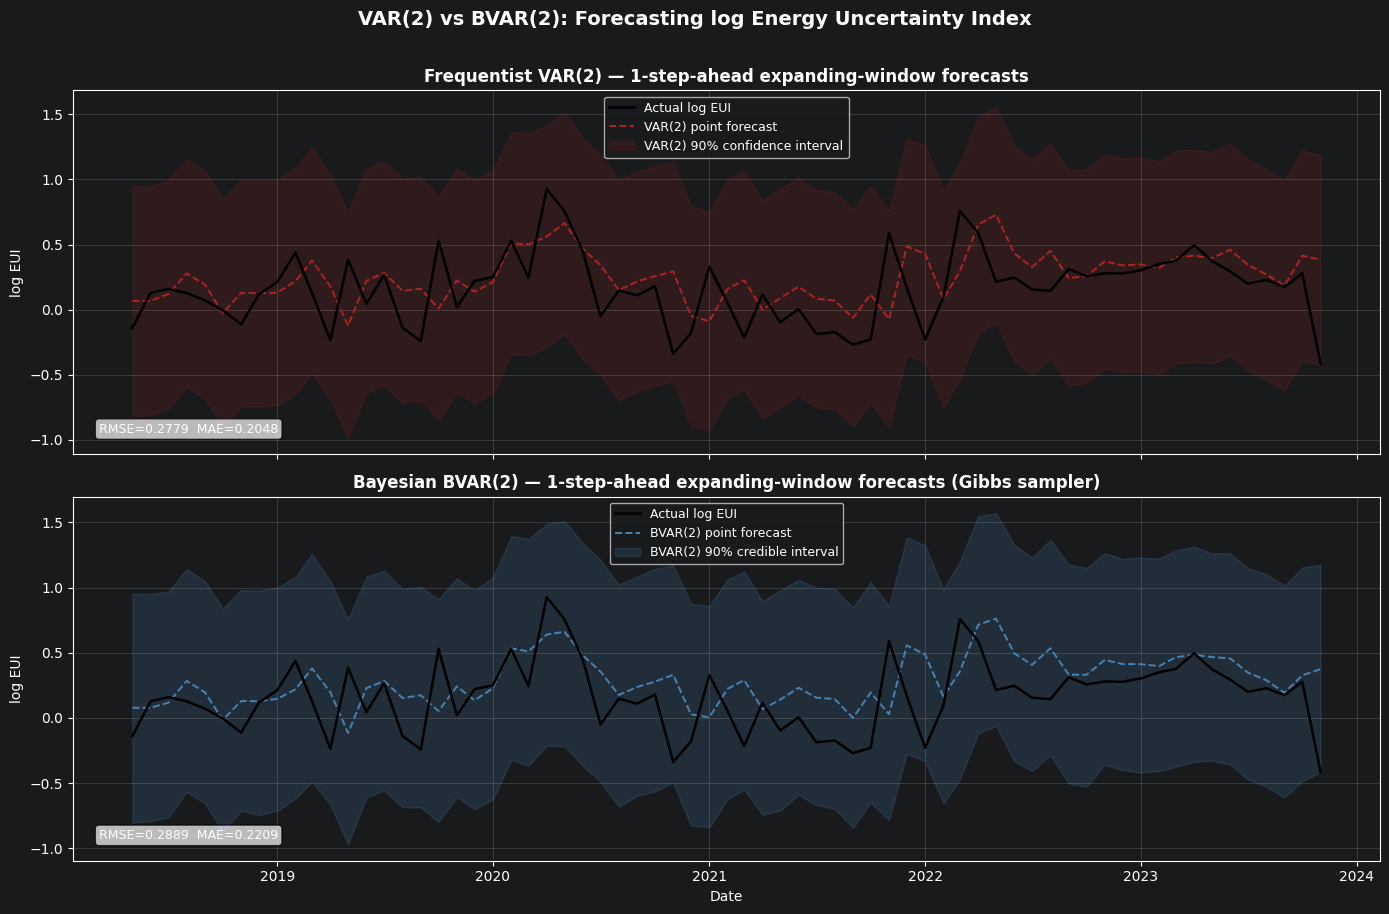

Figure saved to var_vs_bvar_forecast.png


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# ── Top panel: Frequentist VAR ────────────────────────────────────────────────
ax = axes[0]
ax.plot(actual.index, actual.values, color="black", lw=1.8,
        label="Actual log EUI", zorder=5)
ax.plot(var_forecast_series.index, var_forecast_series.values,
        color="firebrick", lw=1.4, ls="--", label="VAR(2) point forecast")
ax.fill_between(
    var_lower_series.index,
    var_lower_series.values,
    var_upper_series.values,
    color="firebrick", alpha=0.15, label="VAR(2) 90% confidence interval"
)
ax.set_title(
    "Frequentist VAR(2) — 1-step-ahead expanding-window forecasts",
    fontsize=12, fontweight="bold"
)
ax.set_ylabel("log EUI")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
rmse_var = rmse(actual, var_forecast_series)
mae_var  = mae(actual, var_forecast_series)
ax.text(0.02, 0.06,
        f"RMSE={rmse_var:.4f}  MAE={mae_var:.4f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

# ── Bottom panel: Bayesian BVAR ───────────────────────────────────────────────
ax = axes[1]
ax.plot(actual.index, actual.values, color="black", lw=1.8,
        label="Actual log EUI", zorder=5)
ax.plot(bvar_forecast_series.index, bvar_forecast_series.values,
        color="steelblue", lw=1.4, ls="--", label="BVAR(2) point forecast")
ax.fill_between(
    bvar_lower_series.index,
    bvar_lower_series.values,
    bvar_upper_series.values,
    color="steelblue", alpha=0.20, label="BVAR(2) 90% credible interval"
)
ax.set_title(
    "Bayesian BVAR(2) — 1-step-ahead expanding-window forecasts (Gibbs sampler)",
    fontsize=12, fontweight="bold"
)
ax.set_ylabel("log EUI")
ax.set_xlabel("Date")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
rmse_bvar = rmse(actual, bvar_forecast_series)
mae_bvar  = mae(actual, bvar_forecast_series)
ax.text(0.02, 0.06,
        f"RMSE={rmse_bvar:.4f}  MAE={mae_bvar:.4f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

fig.suptitle(
    "VAR(2) vs BVAR(2): Forecasting log Energy Uncertainty Index",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("../bayesian/plots/var_vs_bvar_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to var_vs_bvar_forecast.png")

### Uncertainty width over time

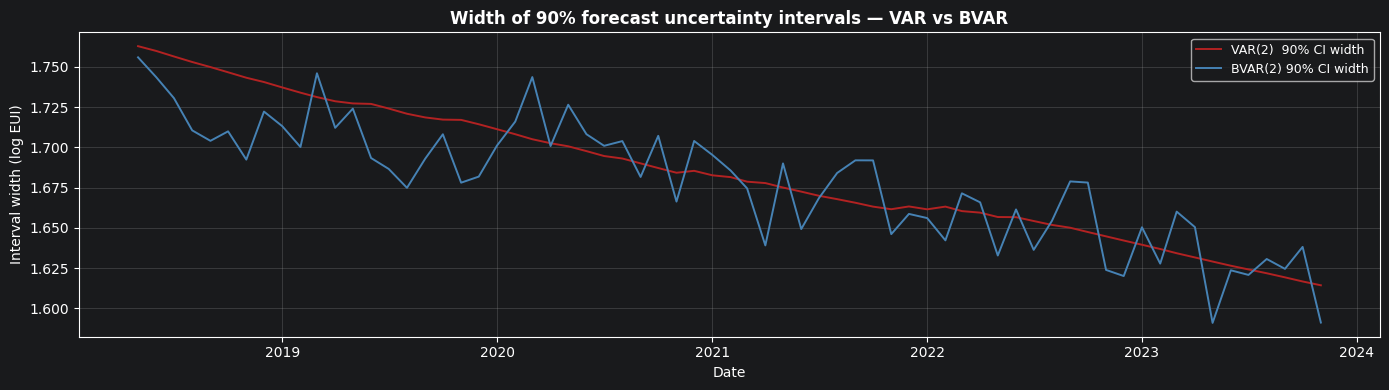

Mean VAR  CI width : 1.6846
Mean BVAR CI width : 1.6783


In [16]:
var_width  = var_upper_series  - var_lower_series
bvar_width = bvar_upper_series - bvar_lower_series

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(var_width.index,  var_width.values,
        color="firebrick",  lw=1.4, label="VAR(2)  90% CI width")
ax.plot(bvar_width.index, bvar_width.values,
        color="steelblue", lw=1.4, label="BVAR(2) 90% CI width")
ax.set_title(
    "Width of 90% forecast uncertainty intervals — VAR vs BVAR",
    fontsize=12, fontweight="bold"
)
ax.set_ylabel("Interval width (log EUI)")
ax.set_xlabel("Date")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../bayesian/plots/interval_width_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Mean VAR  CI width : {var_width.mean():.4f}")
print(f"Mean BVAR CI width : {bvar_width.mean():.4f}")

In [17]:
# Compare OLS coefficients vs BVAR posterior means
beta_ols_diag, _ = get_ols_start(
    endog_train.values, p, dummies=event_dummies_full.iloc[:n_train].values
)
beta_posterior_mean = beta_keep.mean(axis=0)   # from your last Gibbs run

labels = (
    ["intercept"] +
    [f"L{lag}.{col}" for lag in range(1, p+1) for col in var_endog_cols] +
    EVENT_COLS
)

comparison = pd.DataFrame({
    "OLS"           : beta_ols_diag.reshape(n, k)[0],
    "BVAR_posterior": beta_posterior_mean.reshape(n, k)[0],
    "Prior_mean"    : beta0_mn.reshape(n, k)[0],
}, index=labels)

print("Equation: log_eui")
print(comparison.round(4))

# Shrinkage ratio: 0 = data wins entirely, 1 = prior wins entirely
denom = comparison["OLS"] - comparison["Prior_mean"]
shrinkage = ((comparison["OLS"] - comparison["BVAR_posterior"]) / denom).where(denom.abs() > 1e-8)
print("\nShrinkage ratio (0=data wins, 1=prior wins):")
print(shrinkage.round(3))
print("\n[Expected] lag rows ≈ 0 (data dominates), dummy rows ≈ 0.9+ (prior dominates)")

Equation: log_eui
                                OLS  BVAR_posterior  Prior_mean
intercept                   -1.6289         -1.5367     -1.6289
L1.log_eui                   0.4113          0.4095      0.4113
L1.log_gpr                   0.1768          0.1762      0.1768
L1.log_cpu                   0.1932          0.1879      0.1932
L1.log_oil_price            -0.1832         -0.1996     -0.1832
L2.log_eui                   0.2480          0.2473      0.2480
L2.log_gpr                  -0.0933         -0.0934     -0.0933
L2.log_cpu                  -0.0815         -0.0827     -0.0815
L2.log_oil_price             0.3696          0.3653      0.3696
MACRO_PANDEMIC_WINDOW        0.1624          0.0565      0.1624
MACRO_CONFLICT_PULSE         0.0286          0.0475      0.0286
MACRO_FINANCIAL_WINDOW      -0.0885         -0.0701     -0.0885
MACRO_ENERGY_DISASTER_PULSE -0.0747         -0.0765     -0.0747
MACRO_CLIMATE_POLICY_PULSE   0.2152          0.2164      0.2152

Shrinkage ratio (0=da